# Método da Bisseção

In [11]:
%load_ext autoreload
%autoreload 2

import sys
from IPython.display import display
import matplotlib.pyplot as plt

caminho = r"C:\Users\PAIVA\Documents\programação\projeto_circuitos_gq1"

if caminho not in sys.path:
    sys.path.append(caminho)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
from pacote_numerico.bissecao import metodo_bissecao

f_circuito = lambda i: -i**3 - 2*i + 10

dados_para_tabela_bis, raiz_aprox, k = metodo_bissecao(f_circuito, 1, 2, 0.0001, 100)
print(raiz_aprox)
print(k)
display(dados_para_tabela_bis)

1.847442626953125
14


,Iteração,x_novo,Erro
0,0,1.500000,0.500000
1,1,1.750000,0.250000
2,2,1.875000,0.125000
3,3,1.812500,0.062500
4,4,1.843750,0.031250
5,5,1.859375,0.015625
6,6,1.851562,0.007812
7,7,1.847656,0.003906
8,8,1.845703,0.001953
9,9,1.846680,0.000977


# Método das Secantes

In [13]:
from pacote_numerico.secantes import metodo_secantes

dados_para_tabela_sec, raiz_aprox, k = metodo_secantes(f_circuito, 1, 2, e1=1e-4, e2=1e-4)
print(raiz_aprox)
print(k)
display(dados_para_tabela_sec)

1.847418715416474
4


,Iteração,x0,x1,x_novo,f(x_novo),erro_1,erro2
0,1,1.000000,2.000000,1.777778,0.825789,0.825789,0.222222
1,2,2.000000,1.777778,1.842718,0.057408,0.057408,0.064941
2,3,1.777778,1.842718,1.847570,-0.001852,0.001852,0.004852
3,4,1.842718,1.847570,1.847419,0.000004,0.000004,0.000152


# Método Newton-Raphson

In [14]:
from pacote_numerico.newton_raphson import newton_raphson

derivada_f_circuito = lambda i: -3*i**2 - 2

dados_para_tabela_new, raiz_aprox, k = newton_raphson(f_circuito, derivada_f_circuito, 1.5, 1e-4, 1e-4)
print(raiz_aprox)
print(k)
display(dados_para_tabela_new)


1.847420763493156
3


,Iteração,X_novo,f(x),Erro
0,1,1.914286,0.843452,0.414286
1,2,1.849372,0.023926,0.064914
2,3,1.847421,0.000021,0.001951


# Comparações de convergência

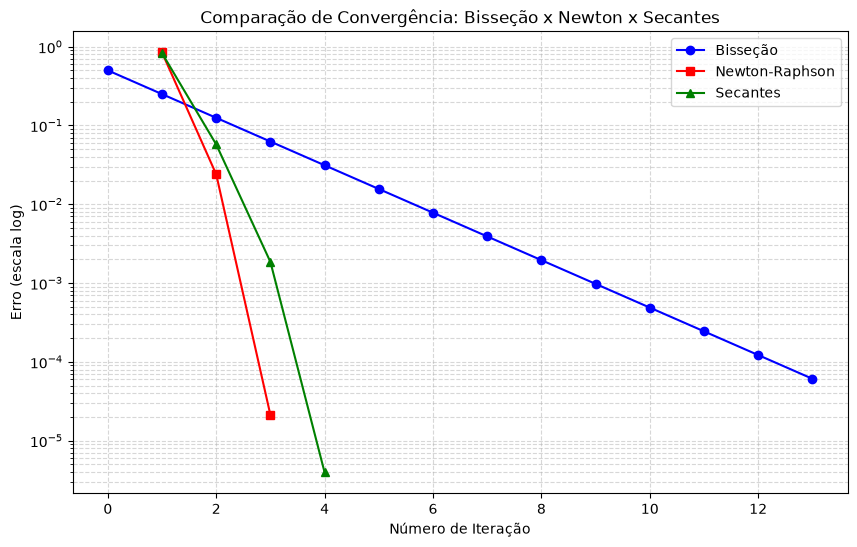

In [15]:
plt.figure(figsize=(10,6))

plt.plot(dados_para_tabela_bis['Iteração'], dados_para_tabela_bis['Erro'], marker='o', color='blue', label='Bisseção')
plt.plot(dados_para_tabela_new['Iteração'], dados_para_tabela_new['f(x)'], marker='s', color='red', label='Newton-Raphson')
plt.plot(dados_para_tabela_sec['Iteração'], dados_para_tabela_sec['erro_1'], marker='^', color='green', label="Secantes")

plt.yscale('log')
plt.xlabel('Número de Iteração')
plt.ylabel('Erro (escala log)')
plt.title('Comparação de Convergência: Bisseção x Newton x Secantes')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.show()